### **Entrega 2 — Detecção de Duplicatas (2,5 pts)**

Construa uma função detectar_duplicatas(textos, limiar=0.85) que receba a lista de manifestações e retorne todos os pares com similaridade acima do limiar. Justifique a escolha do limiar e apresente:

- A matriz de similaridade completa (heatmap);
- A lista de pares duplicados encontrados;
- Uma análise de falsos positivos e falsos negativos (compare com as duplicatas reais do dataset).

In [4]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from sentence_transformers import SentenceTransformer

with open('../data/manifestacoes.json', encoding='utf-8') as f:
    data = json.load(f)

df = pd.DataFrame(data)

textos = df["texto"].tolist()
ids = df["id"].tolist()

model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

## 1. Matriz de Similaridade (heatmap)

In [5]:
embeddings = model.encode(textos, normalize_embeddings=True)
sim = cosine_similarity(embeddings)
print(sim.shape)


(40, 40)


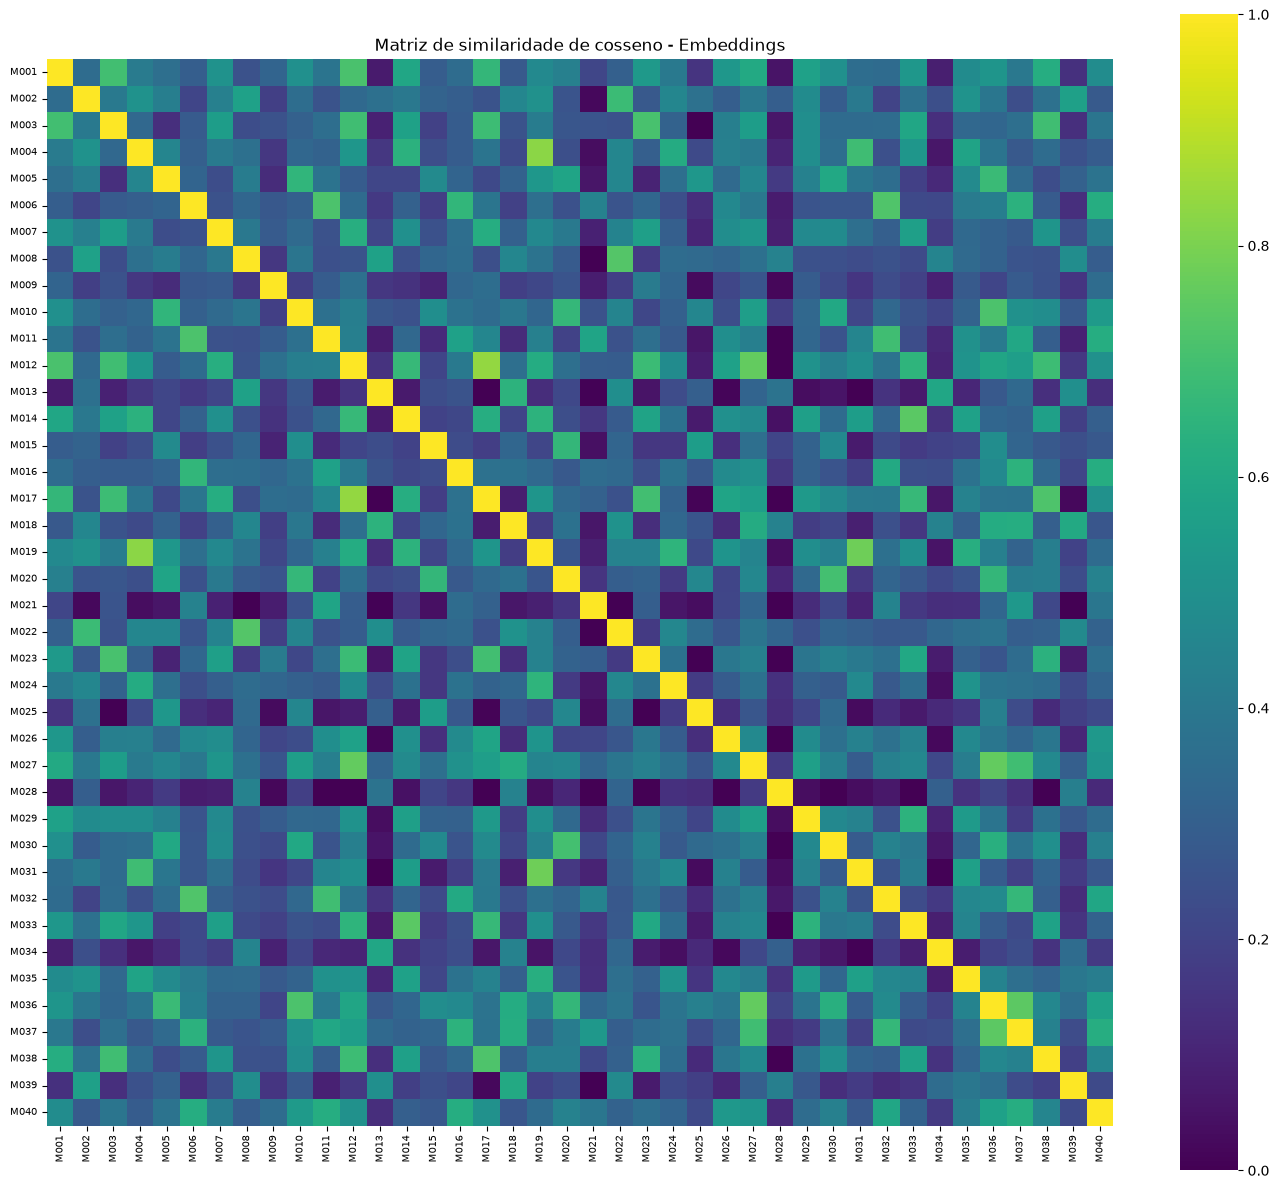

In [6]:
plt.figure(figsize=(14, 12))
sns.heatmap(sim, xticklabels=ids, yticklabels=ids, cmap="viridis", vmin=0, vmax=1, square=True)
plt.title("Matriz de similaridade de cosseno - Embeddings")
plt.xticks(rotation=90, fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()


## 2. Lista de duplicados encontrados

In [7]:
def detectar_duplicatas(textos, limiar=0.85):
    emb = model.encode(textos, normalize_embeddings=True)
    sim = cosine_similarity(emb)

    pares = []
    for i in range(len(textos)):
        for j in range(i + 1, len(textos)):  # j > i: ignora a diagonal e evita pares repetidos
            if sim[i, j] >= limiar:
                pares.append((i, j, round(float(sim[i, j]), 4)))

    return sorted(pares, key=lambda p: p[2], reverse=True)


**Escolha do limiar:** com 0.85 nenhum par é encontrado, e a contagem de pares por limiar foi:
0.8 → 2 | 0.7 → 15 | 0.6 → 65 | 0.5 → 131.
Abaixo de 0.7 o número de pares explode (entram pares que só compartilham o tema geral), mas os pares M003×M017 (0.686) e M003×M038 (0.693) ficam logo abaixo de 0.7. Por isso usamos **0.68**. *(ajuste conforme sua análise)*

In [8]:
LIMITE = 0.67

resultado = detectar_duplicatas(textos, limiar=LIMITE)

duplicatas = pd.DataFrame(
    [(ids[i], ids[j], s) for i, j, s in resultado],
    columns=["id_1", "id_2", "similaridade"],
)
print(f"{len(duplicatas)} pares encontrados")
duplicatas


29 pares encontrados


,id_1,id_2,similaridade
0,M012,M017,0.8361
1,M004,M019,0.8277
2,M019,M031,0.7786
3,M012,M027,0.7595
4,M027,M036,0.7582
5,M036,M037,0.7477
6,M014,M033,0.7448
7,M008,M022,0.7334
8,M006,M032,0.7237
9,M017,M038,0.7214


In [9]:
# Textos lado a lado para conferir cada par
for id_1, id_2, s in duplicatas.itertuples(index=False):
    print(f"{id_1} x {id_2} (sim = {s})")
    print("  ", df.loc[df["id"] == id_1, "texto"].values[0])
    print("  ", df.loc[df["id"] == id_2, "texto"].values[0])
    print()


M012 x M017 (sim = 0.8361)
   A rua principal do bairro está com o asfalto muito deteriorado e apresenta diversos pontos onde surgiram buracos após as últimas chuvas. Os moradores relatam que os veículos precisam reduzir a velocidade ou fazer desvios para evitar os trechos mais danificados. Durante a noite, a situação fica ainda mais difícil porque parte da iluminação da via também apresenta problemas. Além do desconforto para quem utiliza a rua diariamente, existe preocupação com motociclistas e com possíveis acidentes. A comunidade solicita uma vistoria técnica, recuperação dos trechos danificados e acompanhamento das condições do pavimento após novos períodos de chuva.
   O asfalto está todo esburacado na avenida principal do bairro. Existem vários trechos danificados que dificultam a circulação de veículos.

M004 x M019 (sim = 0.8277)
   A iluminação pública está fraca em vários pontos do bairro e a população evita caminhar pela região durante a noite. Solicito vistoria e manutençã

## 3. Análise de falsos positivos e falsos negativos

Gabarito de duplicatas reais, montado por leitura manual do dataset. **Revise antes de usar** (os pares com `?` são os mais discutíveis).

In [10]:
gabarito = [
    ("M003", "M017"),  # buraco/asfalto na avenida
    ("M003", "M038"),
    ("M017", "M038"),
    ("M012", "M017"),  # ? versão longa do mesmo problema
    ("M019", "M031"),  # praça escura
    ("M004", "M019"),  # ? iluminação fraca à noite
    ("M008", "M022"),  # posto sem atendimento
    ("M006", "M032"),  # lixo em terreno
    ("M013", "M034"),  # falta de remédio
]

# tuplas ordenadas, para (A, B) e (B, A) contarem como o mesmo par
gabarito_set = {tuple(sorted(par)) for par in gabarito}
encontrados_set = {tuple(sorted((a, b))) for a, b in zip(duplicatas["id_1"], duplicatas["id_2"])}


In [11]:
verdadeiros_positivos = encontrados_set & gabarito_set
falsos_positivos = encontrados_set - gabarito_set
falsos_negativos = gabarito_set - encontrados_set

print(f"Verdadeiros positivos: {len(verdadeiros_positivos)}")
print(f"Falsos positivos:      {len(falsos_positivos)}")
print(f"Falsos negativos:      {len(falsos_negativos)}")


Verdadeiros positivos: 8
Falsos positivos:      21
Falsos negativos:      1


In [12]:
def similaridade(id_a, id_b):
    return round(float(sim[ids.index(id_a), ids.index(id_b)]), 4)

print("FALSOS POSITIVOS (encontrados, mas não são duplicata real):")
for a, b in sorted(falsos_positivos):
    print(f"  {a} x {b}  sim = {similaridade(a, b)}")

print("\nFALSOS NEGATIVOS (duplicata real que não foi encontrada):")
for a, b in sorted(falsos_negativos):
    print(f"  {a} x {b}  sim = {similaridade(a, b)}")


FALSOS POSITIVOS (encontrados, mas não são duplicata real):
  M001 x M003  sim = 0.6985
  M001 x M012  sim = 0.7138
  M002 x M022  sim = 0.6812
  M003 x M012  sim = 0.6946
  M003 x M023  sim = 0.7071
  M004 x M031  sim = 0.6913
  M005 x M036  sim = 0.676
  M006 x M011  sim = 0.7182
  M010 x M036  sim = 0.7179
  M011 x M032  sim = 0.6936
  M012 x M014  sim = 0.6701
  M012 x M023  sim = 0.6831
  M012 x M027  sim = 0.7595
  M012 x M038  sim = 0.6862
  M014 x M033  sim = 0.7448
  M017 x M023  sim = 0.6974
  M017 x M033  sim = 0.6717
  M020 x M030  sim = 0.7029
  M027 x M036  sim = 0.7582
  M027 x M037  sim = 0.6944
  M036 x M037  sim = 0.7477

FALSOS NEGATIVOS (duplicata real que não foi encontrada):
  M013 x M034  sim = 0.5915


In [13]:
linhas = []
for limiar in [0.8, 0.75, 0.7, 0.68, 0.65, 0.6]:
    achados = {tuple(sorted((ids[i], ids[j]))) for i, j, s in detectar_duplicatas(textos, limiar=limiar)}
    linhas.append({
        "limiar": limiar,
        "pares encontrados": len(achados),
        "verdadeiros positivos": len(achados & gabarito_set),
        "falsos positivos": len(achados - gabarito_set),
        "falsos negativos": len(gabarito_set - achados),
    })

pd.DataFrame(linhas)

,limiar,pares encontrados,verdadeiros positivos,falsos positivos,falsos negativos
0,0.80,2,2,0,7
1,0.75,5,3,2,6
2,0.70,15,6,9,3
3,0.68,26,8,18,1
4,0.65,37,8,29,1
5,0.60,65,8,57,1


## Justificativa do limiar

**Por que não 0.85.** Com o modelo `paraphrase-multilingual-MiniLM-L12-v2`, o maior score da base é 0.836 (M012 × M017), então o limiar de 0.85 não retorna nenhum par. Duplicatas semânticas descritas com palavras diferentes ficam, nesse modelo, na faixa de 0.68 a 0.83, e por isso o valor foi calibrado nos dados.

**Comparação de limiares** (gabarito manual com 9 pares de duplicatas reais):

| Limiar | Pares | VP | FP | FN | Precisão | Recall |
|---|---|---|---|---|---|---|
| 0.80 | 2 | 2 | 0 | 7 | 1.00 | 0.22 |
| 0.75 | 5 | 3 | 2 | 6 | 0.60 | 0.33 |
| 0.70 | 15 | 6 | 9 | 3 | 0.40 | 0.67 |
| **0.68** | **26** | **8** | **18** | **1** | **0.31** | **0.89** |
| 0.65 | 37 | 8 | 29 | 1 | 0.22 | 0.89 |
| 0.60 | 65 | 8 | 57 | 1 | 0.12 | 0.89 |

**Critério da escolha.** Foi adotado **0.68**. Acima dele, o recall cai rápido (0.67 em 0.70 e 0.33 em 0.75), porque duplicatas reais como M003 × M017 (0.686) e M003 × M038 (0.693) ficam de fora. Abaixo dele, o recall não melhora (fica em 0.89) e só aumenta o número de falsos positivos. Além disso, o limiar de 0.60 retornaria 65 pares, muito acima do esperado para uma base em que cerca de 15% das manifestações são duplicatas.

**Trade-off no contexto da ouvidoria.** Numa triagem, um par sugerido passa por revisão humana, então um falso positivo custa apenas uma checagem a mais, enquanto um falso negativo deixa duas manifestações do mesmo problema tramitando separadamente. Por isso a escolha priorizou o recall. O custo é a precisão baixa (0.31): a maioria dos pares sugeridos é só do mesmo tema geral (ex.: M027 × M036, M036 × M037, M014 × M033), sem ser o mesmo problema. Uma alternativa é operar em dois níveis: pares com score ≥ 0.80 tratados como duplicata provável (precisão 1.00 nesta base) e pares entre 0.68 e 0.80 apenas como sugestão para revisão.

**Limitações.** O limiar foi escolhido observando o próprio gabarito, então as métricas são otimistas, e o gabarito (9 pares) é pequeno e depende do julgamento do avaliador. O falso negativo M013 × M034 (0.59) mostra um limite do modelo: um relato pessoal ("minha mãe precisa retirar um medicamento...") e um relato genérico ("falta de medicamentos básicos...") descrevem o mesmo problema, mas ficam distantes no espaço vetorial.